# Dataset Selection and Preprocessing

This notebook presents the selection, inspection, and preprocessing of the three datasets used in this project.

The datasets are prepared for clustering, dimensionality reduction, anomaly detection, and semi-supervised learning. All preprocessing decisions are supported by the characteristics and results of each dataset.

### 1. Dataset Selection

Three datasets were independently selected according to the requirements of the task:

1. **Room Occupancy Estimation** — structured clustering dataset
2. **QSAR Oral Toxicity** — high-dimensional dataset
3. **MetroPT-3** — dataset with partial/weak ground-truth labels

#### 1.1 Room Occupancy Estimation Dataset

- **Purpose:** Structured clustering dataset
- **Domain:** Environmental and building sensor data
- **Samples:** 10,129
- **Numerical features:** 16
- **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/864/room%2Boccupancy%2Bestimation)
- **License:** Creative Commons Attribution 4.0 (CC BY 4.0)

This dataset contains readings from temperature, light, sound, CO₂, and motion sensors. It satisfies the requirement of at least 2,000 samples and 12 numerical features.

It was selected because it represents a new sensor-based domain and is suitable for identifying natural groups of room conditions. The occupancy count will not be used to create clusters. It will only be retained for external evaluation of the clustering results.

#### 1.2 QSAR Oral Toxicity Dataset

- **Purpose:** High-dimensional dataset
- **Domain:** Computational toxicology
- **Samples:** 8,992
- **Numerical features:** 1,024 binary molecular fingerprints
- **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/508/qsar+oral+toxicity)
- **License:** Creative Commons Attribution 4.0 (CC BY 4.0)

Each row represents a chemical compound using 1,024 binary molecular fingerprints. The class label indicates whether the compound produced a positive or negative oral-toxicity response.

This dataset satisfies the requirement of at least 5,000 samples and 100 features. It was selected because its large number of features makes it suitable for studying the curse of dimensionality, dimensionality-reduction methods, and clustering performance in a high-dimensional space.

The toxicity class will be excluded during unsupervised learning and used only for external evaluation.

#### 1.3 MetroPT-3 Dataset

- **Purpose:** Weakly labelled dataset for anomaly detection and semi-supervised learning
- **Domain:** Railway predictive maintenance
- **Samples:** 1,516,948 time-series observations
- **Sensor signals:** 15
- **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/791/metropt%2B3%2Bdataset)
- **License:** Creative Commons Attribution 4.0 (CC BY 4.0)

MetroPT-3 contains sensor readings collected from the air production unit of a metro train. The signals include pressure, motor current, oil temperature, and electrical control readings.

The dataset does not provide a complete class label for every row. Instead, company maintenance reports identify only a small number of failure periods. Therefore, its ground truth is partial and weak, which reflects a realistic predictive-maintenance problem.

It was selected because it is suitable for anomaly detection and semi-supervised learning, where only limited labelled information is available.

#### 1.4 License and Usage Check

All three datasets are distributed by the UCI Machine Learning Repository under the **Creative Commons Attribution 4.0 International (CC BY 4.0)** license.

This license permits the datasets to be used, shared, and adapted for this project, provided that the original sources are properly credited and any modifications are stated. Therefore, the datasets can be legally used for this academic internship task.

### 2. Environment Setup

The required Python libraries are imported below. A fixed random seed is used to make sampling and experimental results reproducible.

In [49]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    QuantileTransformer
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

print("Libraries imported successfully.")
print("Random seed:", RANDOM_STATE)

Libraries imported successfully.
Random seed: 42


### 3. Dataset File Paths

The notebook and the `datasets` folder are stored directly inside the main project folder. The following paths point to the three raw CSV files and the folder where processed datasets will later be saved.

In [25]:
PROJECT_ROOT = Path.cwd()

RAW_DIR = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"

ROOM_PATH = RAW_DIR / "room_occupancy_estimation.csv"
QSAR_PATH = RAW_DIR / "qsar_oral_toxicity.csv"
METRO_PATH = RAW_DIR / "metropt3_air_compressor.csv"

print("Room Occupancy file found:", ROOM_PATH.exists())
print("QSAR file found:", QSAR_PATH.exists())
print("MetroPT-3 file found:", METRO_PATH.exists())

Room Occupancy file found: True
QSAR file found: True
MetroPT-3 file found: True


### 4. Loading and Initial Inspection

Each dataset will now be loaded and examined separately. The initial inspection includes its shape, first few rows, column names, data types, missing values, and duplicate rows.

#### 4.1 Room Occupancy Estimation Dataset

In [26]:
room_df = pd.read_csv(ROOM_PATH)

print("Dataset loaded successfully.")
print("Shape:", room_df.shape)

display(room_df.head())

Dataset loaded successfully.
Shape: (10129, 19)


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [27]:
print("Column names:")
print(room_df.columns.tolist())

print("\nData types:")
display(room_df.dtypes.to_frame("Data Type"))

print("Total missing values:", room_df.isnull().sum().sum())
print("Duplicate rows:", room_df.duplicated().sum())

Column names:
['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count']

Data types:


,Data Type
Date,str
Time,str
S1_Temp,float64
S2_Temp,float64
S3_Temp,float64
S4_Temp,float64
S1_Light,int64
S2_Light,int64
S3_Light,int64
S4_Light,int64


Total missing values: 0
Duplicate rows: 0


**Observation:** The Room Occupancy dataset contains 10,129 observations and 19 columns. It includes 16 numerical sensor features, two time-related columns (`Date` and `Time`), and one occupancy label. No missing values or duplicate rows were found, so no rows need to be removed or imputed at this stage.

In [28]:
display(room_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


**Observation:** The sensor features are measured on very different scales. For example, temperature values are around 24–29, light reaches 280, CO₂ reaches 1,270, while sound values are mostly below 1. These differences could cause large-valued features to dominate distance-based clustering, so feature scaling is required.

#### Separating Features and Ground-Truth Labels

`Date` and `Time` describe when each reading was recorded, so they will not be used as sensor features. `Room_Occupancy_Count` is the available ground-truth label.

Since this is an unsupervised experiment, the occupancy label will not be provided to the clustering algorithms. It will only be saved for evaluating the discovered clusters later.

In [29]:
room_metadata = room_df[["Date", "Time"]].copy()
room_labels = room_df["Room_Occupancy_Count"].copy()

room_features = room_df.drop(
    columns=["Date", "Time", "Room_Occupancy_Count"]
).copy()

print("Feature matrix shape:", room_features.shape)
print("Label shape:", room_labels.shape)

print("\nOccupancy label distribution:")
display(room_labels.value_counts().sort_index().to_frame("Count"))

Feature matrix shape: (10129, 16)
Label shape: (10129,)

Occupancy label distribution:


,Count
Room_Occupancy_Count,
0,8228
1,459
2,748
3,694


**Observation:** After removing the date, time, and occupancy label, 16 numerical sensor features remain for clustering. The ground-truth labels are imbalanced: most observations represent an empty room, while occupied-room observations are less frequent. These labels will only be used for external cluster evaluation.

#### Outlier Detection

Potential outliers in the continuous sensor features will be identified using the IQR method. The two PIR features are binary, so the IQR method is not appropriate for them.

Outliers will first be examined rather than removed automatically because unusually high sensor readings may represent genuine occupied-room conditions.

In [30]:
continuous_features = room_features.drop(columns=["S6_PIR", "S7_PIR"])

Q1 = continuous_features.quantile(0.25)
Q3 = continuous_features.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (continuous_features < (Q1 - 1.5 * IQR)) |
    (continuous_features > (Q3 + 1.5 * IQR))
)

room_outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_mask.sum(),
    "Outlier Percentage": outlier_mask.mean() * 100
}).sort_values("Outlier Count", ascending=False)

display(room_outlier_summary)

,Outlier Count,Outlier Percentage
S5_CO2_Slope,4033,39.816369
S1_Sound,1772,17.494323
S1_Light,1716,16.941455
S2_Sound,1703,16.813111
S3_Sound,1671,16.497186
S5_CO2,1657,16.358969
S2_Light,1017,10.040478
S3_Light,950,9.379011
S2_Temp,948,9.359265
S4_Sound,721,7.118176


**Observation:** The IQR method identifies many extreme values, particularly in CO₂ slope, sound, light, and CO₂ readings. These values are retained because they may represent genuine changes caused by room occupancy rather than data-entry errors. Their effect will instead be handled and tested through RobustScaler during the scaling comparison.

#### Correlation Analysis

Correlation analysis is used to identify sensor features that contain highly similar information. Strongly correlated features may give repeated information extra influence during clustering.

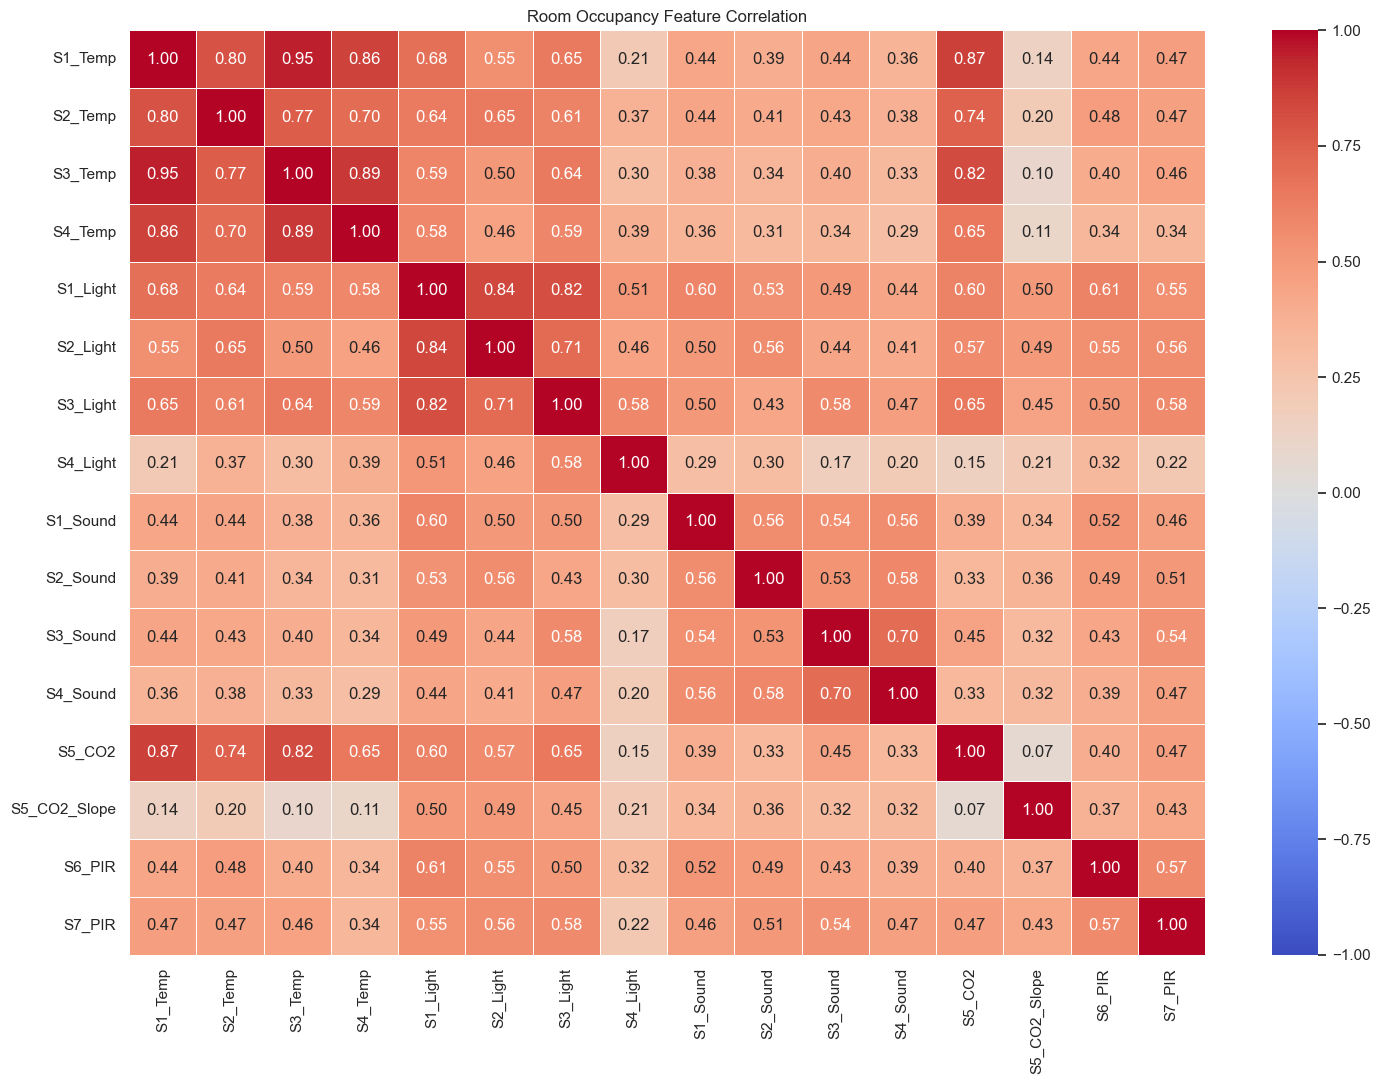

Feature pairs with correlation above 0.90:


,,Absolute Correlation
S1_Temp,S3_Temp,0.948839


In [31]:
room_correlation = room_features.corr()

plt.figure(figsize=(15, 11))
sns.heatmap(
    room_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Room Occupancy Feature Correlation")
plt.tight_layout()
plt.show()

upper_triangle = room_correlation.abs().where(
    np.triu(np.ones(room_correlation.shape), k=1).astype(bool)
)

high_correlation_pairs = upper_triangle.stack()
high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs > 0.90
].sort_values(ascending=False)

print("Feature pairs with correlation above 0.90:")
display(high_correlation_pairs.to_frame("Absolute Correlation"))

**Observation:** Most feature pairs remain below the selected correlation threshold. Only `S1_Temp` and `S3_Temp` show very strong correlation (0.949), indicating that these sensors contain similar temperature information. VIF is calculated next to examine multicollinearity across all features.

In [32]:
room_vif_data = pd.DataFrame(
    StandardScaler().fit_transform(room_features),
    columns=room_features.columns
)

room_vif = pd.DataFrame({
    "Feature": room_vif_data.columns,
    "VIF": [
        variance_inflation_factor(room_vif_data.values, i)
        for i in range(room_vif_data.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(room_vif)

,Feature,VIF
0,S1_Temp,29.527230
2,S3_Temp,18.443998
4,S1_Light,9.904918
12,S5_CO2,6.767583
3,S4_Temp,6.400014
6,S3_Light,6.322680
5,S2_Light,5.148298
1,S2_Temp,4.075899
7,S4_Light,3.138559
10,S3_Sound,2.651366


**Observation:** `S1_Temp` shows the highest multicollinearity and strongly overlaps with `S3_Temp`. Therefore, `S1_Temp` is removed to reduce redundant influence during clustering.

In [33]:
room_features_clean = room_features.drop(columns=["S1_Temp"])

room_vif_clean_data = pd.DataFrame(
    StandardScaler().fit_transform(room_features_clean),
    columns=room_features_clean.columns
)

room_vif_after = pd.DataFrame({
    "Feature": room_vif_clean_data.columns,
    "VIF": [
        variance_inflation_factor(room_vif_clean_data.values, i)
        for i in range(room_vif_clean_data.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("Shape after removing S1_Temp:", room_features_clean.shape)
display(room_vif_after)

Shape after removing S1_Temp: (10129, 15)


,Feature,VIF
1,S3_Temp,9.930084
3,S1_Light,6.549239
5,S3_Light,6.232093
2,S4_Temp,5.875951
11,S5_CO2,5.814926
4,S2_Light,4.555792
0,S2_Temp,3.594031
9,S3_Sound,2.650067
6,S4_Light,2.449598
10,S4_Sound,2.336187


**Observation:** After removing `S1_Temp`, the maximum VIF decreased from 29.53 to 9.93. The remaining 15 features are retained.

#### 4.2 QSAR Oral Toxicity Dataset

In [34]:
qsar_df = pd.read_csv(QSAR_PATH, sep=";", header=None)

print("Dataset loaded successfully.")
print("Shape:", qsar_df.shape)

display(qsar_df.head())

Dataset loaded successfully.
Shape: (8992, 1025)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,...,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,negative
1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,negative
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,negative
3,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,negative
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,negative


In [35]:
qsar_df.columns = [
    *[f"Fingerprint_{i}" for i in range(1, 1025)],
    "Toxicity_Class"
]

print("Total missing values:", qsar_df.isnull().sum().sum())
print("Duplicate rows:", qsar_df.duplicated().sum())

print("\nToxicity class distribution:")
display(qsar_df["Toxicity_Class"].value_counts().to_frame("Count"))

fingerprint_values = np.unique(
    qsar_df.drop(columns="Toxicity_Class").values
)
print("Unique fingerprint values:", fingerprint_values)

Total missing values: 0
Duplicate rows: 477

Toxicity class distribution:


,Count
Toxicity_Class,
negative,8251
positive,741


Unique fingerprint values: [0 1]


**Observation:** The QSAR dataset has no missing values, but it contains 477 duplicate rows. Its 1,024 features are binary, and the toxicity classes are highly imbalanced.

In [36]:
qsar_clean = qsar_df.drop_duplicates().reset_index(drop=True)

qsar_labels = qsar_clean["Toxicity_Class"].copy()
qsar_features = qsar_clean.drop(columns="Toxicity_Class").copy()

constant_features = qsar_features.columns[
    qsar_features.nunique() <= 1
]

qsar_features_clean = qsar_features.drop(
    columns=constant_features
)

print("Shape after removing duplicates:", qsar_clean.shape)
print("Constant features removed:", len(constant_features))
print("Final feature shape:", qsar_features_clean.shape)

print("\nClass distribution after cleaning:")
display(qsar_labels.value_counts().to_frame("Count"))

Shape after removing duplicates: (8515, 1025)
Constant features removed: 0
Final feature shape: (8515, 1024)

Class distribution after cleaning:


,Count
Toxicity_Class,
negative,7796
positive,719


#### QSAR Outlier Analysis

The IQR method is not applied separately to binary fingerprints because values of 0 and 1 are both valid. Instead, the total number of active fingerprints in each compound is examined to identify unusually sparse or dense molecular representations.

In [37]:
# Count the number of active fingerprints in each compound
active_fingerprint_count = qsar_features_clean.sum(axis=1)

# Calculate IQR limits for the active fingerprint counts
Q1 = active_fingerprint_count.quantile(0.25)
Q3 = active_fingerprint_count.quantile(0.75)
IQR = Q3 - Q1

# Identify compounds with unusually low or high fingerprint counts
qsar_outlier_mask = (
    (active_fingerprint_count < Q1 - 1.5 * IQR) |
    (active_fingerprint_count > Q3 + 1.5 * IQR)
)

print("Active fingerprint statistics:")
display(active_fingerprint_count.describe().to_frame("Value"))

print("Potential unusual compounds:", qsar_outlier_mask.sum())
print(
    "Percentage:",
    round(qsar_outlier_mask.mean() * 100, 2),
    "%"
)

Active fingerprint statistics:


,Value
count,8515.000000
mean,95.741045
std,49.160784
min,2.000000
25%,62.000000
50%,89.000000
75%,120.000000
max,911.000000


Potential unusual compounds: 207
Percentage: 2.43 %


**Observation:** Only 2.43% of compounds have unusual fingerprint counts. They are retained because they may represent valid chemical structures rather than data errors.

#### QSAR Correlation and Multicollinearity

A full 1,024-feature heatmap would be unreadable. Therefore, the 30 fingerprints with the highest variance are examined. This subset contains the binary features that vary most across compounds.

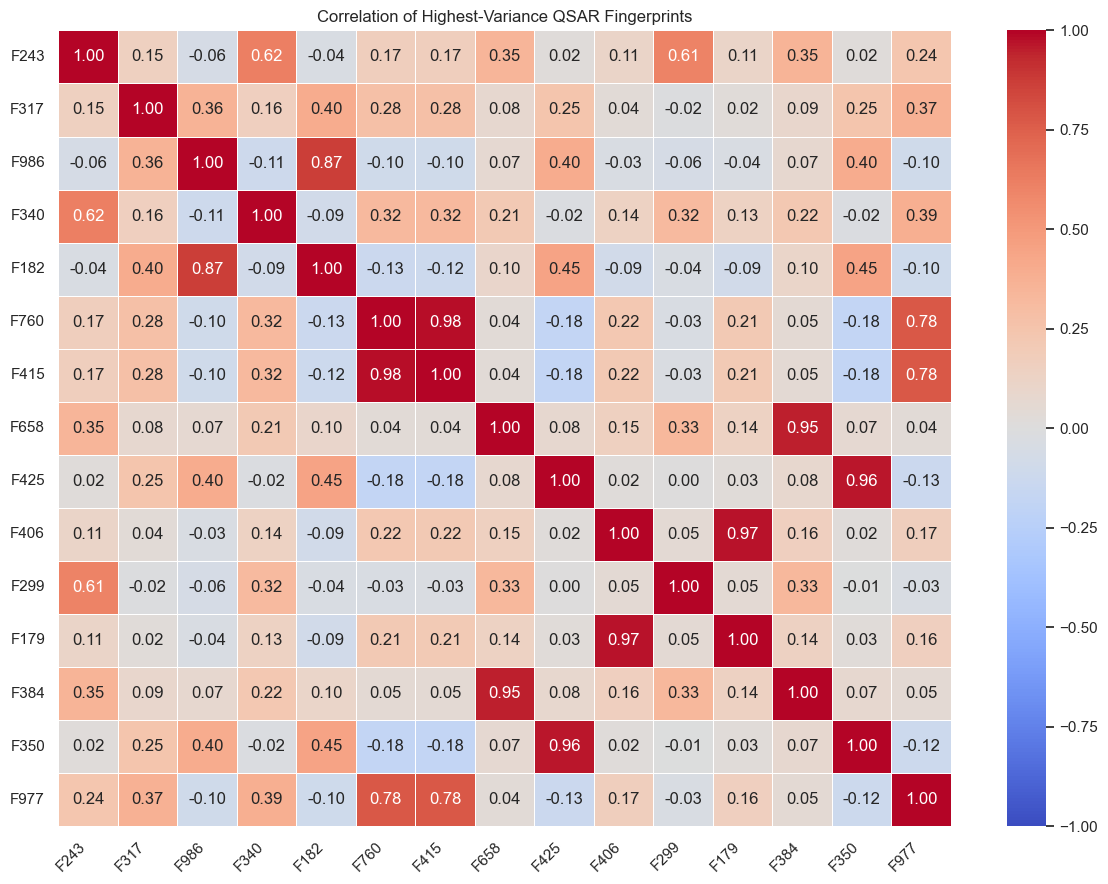

Highly correlated pairs: 18


,,Absolute Correlation
Fingerprint_760,Fingerprint_415,0.980911
Fingerprint_961,Fingerprint_289,0.972436
Fingerprint_406,Fingerprint_179,0.968851
Fingerprint_409,Fingerprint_117,0.965702
Fingerprint_425,Fingerprint_350,0.964883
Fingerprint_474,Fingerprint_468,0.958814
Fingerprint_658,Fingerprint_384,0.950986
Fingerprint_474,Fingerprint_17,0.934566
Fingerprint_289,Fingerprint_223,0.927105
Fingerprint_468,Fingerprint_17,0.926850


In [38]:
# Select the 30 most variable fingerprints for correlation analysis
qsar_top_features = (
    qsar_features_clean.var()
    .nlargest(30)
    .index
)

qsar_top_data = qsar_features_clean[qsar_top_features]
qsar_correlation = qsar_top_data.corr()

# Plot only the top 15 features to keep the heatmap readable
plot_features = qsar_top_features[:15]
plot_correlation = qsar_features_clean[plot_features].corr()

# Shorten feature names for display
short_names = {
    feature: feature.replace("Fingerprint_", "F")
    for feature in plot_features
}
plot_correlation = plot_correlation.rename(
    index=short_names,
    columns=short_names
)

plt.figure(figsize=(12, 9))
sns.heatmap(
    plot_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation of Highest-Variance QSAR Fingerprints")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Check strong correlations across all 30 selected features
upper_triangle = qsar_correlation.abs().where(
    np.triu(np.ones(qsar_correlation.shape), k=1).astype(bool)
)

qsar_high_correlation = upper_triangle.stack()
qsar_high_correlation = qsar_high_correlation[
    qsar_high_correlation > 0.90
].sort_values(ascending=False)

print("Highly correlated pairs:", len(qsar_high_correlation))
display(qsar_high_correlation.to_frame("Absolute Correlation"))

**Observation:** Among the 30 examined fingerprints, 18 pairs have correlations above 0.90, indicating redundant molecular information.

In [39]:
# Standardize the selected fingerprints before calculating VIF
qsar_vif_data = pd.DataFrame(
    StandardScaler().fit_transform(qsar_top_data),
    columns=qsar_top_data.columns
)

# Calculate VIF for the 30 highest-variance fingerprints
qsar_vif = pd.DataFrame({
    "Feature": qsar_vif_data.columns,
    "VIF": [
        variance_inflation_factor(qsar_vif_data.values, i)
        for i in range(qsar_vif_data.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(qsar_vif.head(15))

,Feature,VIF
5,Fingerprint_760,29.028972
6,Fingerprint_415,27.297654
22,Fingerprint_289,21.805883
21,Fingerprint_961,21.419052
18,Fingerprint_474,17.122980
9,Fingerprint_406,16.800032
11,Fingerprint_179,16.671515
25,Fingerprint_409,15.966145
8,Fingerprint_425,15.545612
26,Fingerprint_117,15.505425


**Observation:** Several high-variance fingerprints have VIF values above 10, confirming multicollinearity. One feature from each pair correlated above 0.90 is removed.

In [40]:
# Select one redundant feature from each highly correlated pair
qsar_redundant_features = [
    column
    for column in upper_triangle.columns
    if (upper_triangle[column] > 0.90).any()
]

# Remove the selected redundant fingerprints
qsar_features_reduced = qsar_features_clean.drop(
    columns=qsar_redundant_features
)

print("Redundant features removed:", len(qsar_redundant_features))
print("Removed features:", qsar_redundant_features)
print("Final QSAR feature shape:", qsar_features_reduced.shape)

Redundant features removed: 12
Removed features: ['Fingerprint_415', 'Fingerprint_179', 'Fingerprint_384', 'Fingerprint_350', 'Fingerprint_343', 'Fingerprint_468', 'Fingerprint_17', 'Fingerprint_961', 'Fingerprint_289', 'Fingerprint_96', 'Fingerprint_117', 'Fingerprint_223']
Final QSAR feature shape: (8515, 1012)


**Observation:** Twelve strongly correlated fingerprints were removed, leaving 1,012 features for further analysis.

#### 4.3 MetroPT-3 Dataset

In [41]:
# Load the large MetroPT-3 sensor dataset
metro_df = pd.read_csv(
    METRO_PATH,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", metro_df.shape)

display(metro_df.head())

Dataset loaded successfully.
Shape: (1516948, 17)


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [42]:
# Inspect the MetroPT-3 structure and data quality
print("Column names:")
print(metro_df.columns.tolist())

print("\nTotal missing values:", metro_df.isnull().sum().sum())
print("Duplicate rows:", metro_df.duplicated().sum())

print(
    "Memory usage:",
    round(metro_df.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB"
)

Column names:
['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

Total missing values: 0
Duplicate rows: 0
Memory usage: 283.55 MB


**Observation:** MetroPT-3 contains no missing values or duplicate rows. The `Unnamed: 0` column is an unnecessary row index and will be removed.

In [43]:
# Remove the unnecessary saved index column
metro_clean = metro_df.drop(columns=["Unnamed: 0"]).copy()

# Convert timestamps from text into datetime values
metro_clean["timestamp"] = pd.to_datetime(
    metro_clean["timestamp"],
    errors="coerce"
)

# Remove rows only if their timestamps could not be parsed
invalid_timestamps = metro_clean["timestamp"].isnull().sum()
metro_clean = metro_clean.dropna(subset=["timestamp"])

# Sort the time-series observations chronologically
metro_clean = metro_clean.sort_values("timestamp").reset_index(drop=True)

print("Invalid timestamps removed:", invalid_timestamps)
print("Cleaned shape:", metro_clean.shape)
print("Time range:", metro_clean["timestamp"].min(), "to", metro_clean["timestamp"].max())

Invalid timestamps removed: 0
Cleaned shape: (1516948, 16)
Time range: 2020-02-01 00:00:00 to 2020-09-01 03:59:50


#### Time-Window Aggregation

MetroPT-3 is too large to use directly with every required algorithm. Its readings are recorded approximately every ten seconds, so nearby rows often contain very similar information.

The data will be grouped into non-overlapping ten-minute windows. For continuous sensors, mean, standard deviation, minimum, and maximum values are calculated. For binary signals, the mean represents the proportion of time the signal remained active. This preserves useful behaviour while making later experiments manageable.

In [44]:
# Separate continuous sensors from binary control signals
continuous_columns = [
    "TP2", "TP3", "H1", "DV_pressure",
    "Reservoirs", "Oil_temperature", "Motor_current"
]

binary_columns = [
    "COMP", "DV_eletric", "Towers", "MPG",
    "LPS", "Pressure_switch", "Oil_level",
    "Caudal_impulses"
]

# Use the timestamp as the time-series index
metro_time_data = metro_clean.set_index("timestamp")

# Calculate statistical features for continuous sensors
continuous_windows = metro_time_data[continuous_columns].resample(
    "10min"
).agg(["mean", "std", "min", "max"])

continuous_windows.columns = [
    f"{feature}_{statistic}"
    for feature, statistic in continuous_windows.columns
]

# Calculate the active proportion of each binary signal
binary_windows = metro_time_data[binary_columns].resample(
    "10min"
).mean()

binary_windows.columns = [
    f"{feature}_active_ratio"
    for feature in binary_windows.columns
]

# Combine continuous and binary window features
metro_windows = continuous_windows.join(binary_windows)

# Retain the number of original readings in every window
metro_windows["Window_Observation_Count"] = (
    metro_time_data.resample("10min").size()
)

# Remove empty time windows
metro_windows = metro_windows[
    metro_windows["Window_Observation_Count"] > 0
].copy()

print("Aggregated shape:", metro_windows.shape)
display(metro_windows.head())

Aggregated shape: (25521, 37)


,TP2_mean,TP2_std,TP2_min,TP2_max,TP3_mean,TP3_std,TP3_min,TP3_max,H1_mean,H1_std,H1_min,H1_max,DV_pressure_mean,DV_pressure_std,DV_pressure_min,...,Oil_temperature_min,Oil_temperature_max,Motor_current_mean,Motor_current_std,Motor_current_min,Motor_current_max,COMP_active_ratio,DV_eletric_active_ratio,Towers_active_ratio,MPG_active_ratio,LPS_active_ratio,Pressure_switch_active_ratio,Oil_level_active_ratio,Caudal_impulses_active_ratio,Window_Observation_Count
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.013016,0.001008,-0.014,-0.012,9.053705,0.177553,8.760,9.358,9.038230,0.176852,8.746,9.340,-0.022787,0.000985,-0.024,...,52.325,53.675,0.040000,0.000791,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0,61
2020-02-01 00:10:00,-0.013836,0.000757,-0.016,-0.012,8.480361,0.156157,8.222,8.750,8.466590,0.155983,8.210,8.736,-0.023180,0.000992,-0.024,...,50.325,52.300,0.039590,0.001039,0.0350,0.0400,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0,61
2020-02-01 00:20:00,1.570033,3.580866,-0.026,10.314,9.169833,0.793773,8.068,10.098,7.626233,3.529391,-0.028,10.098,-0.022967,0.001008,-0.024,...,49.625,53.825,3.095708,2.172363,0.0400,6.2825,0.816667,0.183333,0.916667,0.816667,0.0,1.0,1.0,1.0,60
2020-02-01 00:30:00,-0.012820,0.001118,-0.014,-0.010,9.300000,0.182287,8.994,9.608,9.284262,0.182311,8.980,9.592,-0.022656,0.000947,-0.024,...,52.700,53.550,0.727828,1.478098,0.0375,3.9100,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0,61
2020-02-01 00:40:00,-0.013833,0.000763,-0.016,-0.012,8.703833,0.162246,8.436,8.984,8.689200,0.161837,8.422,8.970,-0.023167,0.000994,-0.024,...,51.100,52.875,0.039833,0.000905,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0,60


In [45]:
# Separate the observation count from the sensor features
metro_window_counts = metro_windows["Window_Observation_Count"].copy()
metro_features = metro_windows.drop(
    columns="Window_Observation_Count"
).copy()

# Check missing values created during aggregation
missing_before = metro_features.isnull().sum()
missing_before = missing_before[missing_before > 0]

print("Features with missing values after aggregation:")
display(missing_before.to_frame("Missing Count"))

# Fill missing aggregated values with their feature medians
metro_imputer = SimpleImputer(strategy="median")

metro_features_clean = pd.DataFrame(
    metro_imputer.fit_transform(metro_features),
    columns=metro_features.columns,
    index=metro_features.index
)

print(
    "Remaining missing values:",
    metro_features_clean.isnull().sum().sum()
)
print("Final MetroPT-3 feature shape:", metro_features_clean.shape)

Features with missing values after aggregation:


,Missing Count
TP2_std,8
TP3_std,8
H1_std,8
DV_pressure_std,8
Reservoirs_std,8
Oil_temperature_std,8
Motor_current_std,8


Remaining missing values: 0
Final MetroPT-3 feature shape: (25521, 36)


**Observation:** Aggregation created eight missing standard-deviation values in seven features. Median imputation removed all missing values, leaving 25,521 windows and 36 features.

#### MetroPT-3 Outlier Analysis

Extreme sensor windows are identified using the IQR method but are not removed. Since MetroPT-3 is used for anomaly detection, these unusual values may contain genuine failure behaviour.

In [46]:
# Apply IQR only to continuous aggregated sensor features
metro_continuous_features = metro_features_clean[
    [
        column for column in metro_features_clean.columns
        if "active_ratio" not in column
    ]
]

# Calculate IQR limits
Q1 = metro_continuous_features.quantile(0.25)
Q3 = metro_continuous_features.quantile(0.75)
IQR = Q3 - Q1

# Identify extreme values in each feature
metro_outlier_mask = (
    (metro_continuous_features < Q1 - 1.5 * IQR) |
    (metro_continuous_features > Q3 + 1.5 * IQR)
)

metro_outlier_summary = pd.DataFrame({
    "Outlier Count": metro_outlier_mask.sum(),
    "Outlier Percentage": metro_outlier_mask.mean() * 100
}).sort_values("Outlier Count", ascending=False)

display(metro_outlier_summary.head(15))

print(
    "Windows with at least one IQR outlier:",
    metro_outlier_mask.any(axis=1).sum()
)

,Outlier Count,Outlier Percentage
DV_pressure_std,6512,25.516242
Motor_current_max,5163,20.230398
DV_pressure_max,5158,20.210807
DV_pressure_mean,3428,13.432076
Motor_current_min,2526,9.897731
H1_mean,1680,6.582814
TP2_mean,1599,6.265428
H1_max,1551,6.077348
TP2_min,1530,5.995063
DV_pressure_min,1235,4.839152


Windows with at least one IQR outlier: 11879


**Observation:** About 46.55% of windows contain at least one IQR extreme. `DV_pressure_std` (25.52%) and `Motor_current_max` (20.23%) contain the most. These values are retained because they may represent genuine equipment faults.

#### MetroPT-3 Correlation Analysis

Correlation is examined across all aggregated features. For readability, the heatmap displays the mean continuous readings and binary active ratios, while strong correlations are detected using the complete feature set.

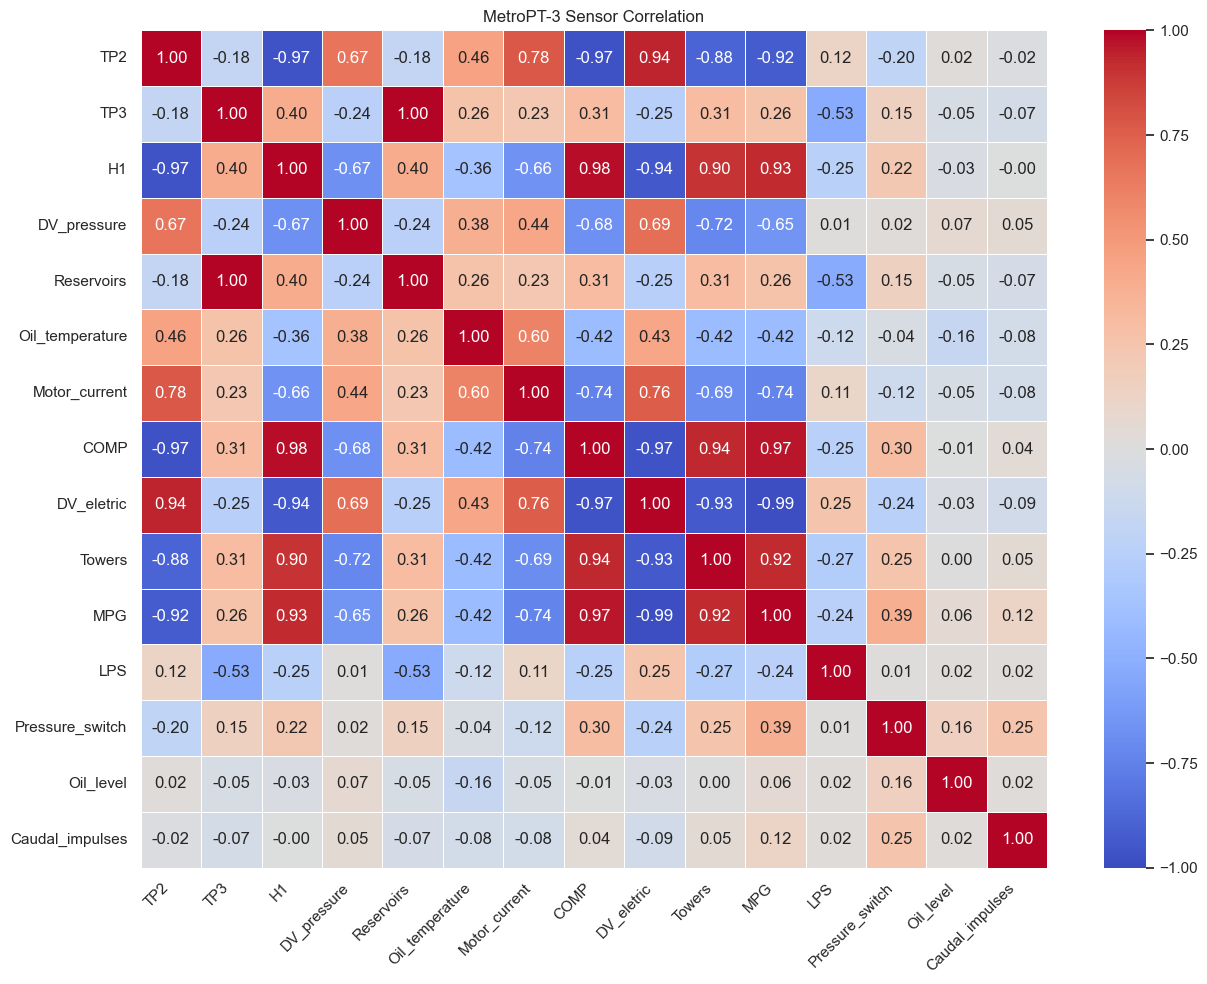

Feature pairs with correlation above 0.90: 26


In [47]:
# Calculate correlation across all aggregated features
metro_correlation = metro_features_clean.corr()

# Select representative features for a readable heatmap
representative_features = [
    column for column in metro_features_clean.columns
    if column.endswith("_mean") or column.endswith("_active_ratio")
]

plot_correlation = metro_features_clean[
    representative_features
].corr()

# Shorten names for display
short_names = {
    column: column.replace("_active_ratio", "").replace("_mean", "")
    for column in representative_features
}

plot_correlation = plot_correlation.rename(
    index=short_names,
    columns=short_names
)

plt.figure(figsize=(13, 10))
sns.heatmap(
    plot_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("MetroPT-3 Sensor Correlation")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detect strong correlations across all 36 features
upper_triangle = metro_correlation.abs().where(
    np.triu(np.ones(metro_correlation.shape), k=1).astype(bool)
)

metro_high_correlation = upper_triangle.stack()
metro_high_correlation = metro_high_correlation[
    metro_high_correlation > 0.90
].sort_values(ascending=False)

print(
    "Feature pairs with correlation above 0.90:",
    len(metro_high_correlation)
)

**Observation:** Twenty-six feature pairs have correlations above 0.90. Pressure sensors and compressor-control signals often change together, indicating substantial multicollinearity.

In [48]:
# Standardize the representative sensor features
metro_vif_data = pd.DataFrame(
    StandardScaler().fit_transform(
        metro_features_clean[representative_features]
    ),
    columns=representative_features
)

# Calculate VIF for the representative features
metro_vif = pd.DataFrame({
    "Feature": metro_vif_data.columns,
    "VIF": [
        variance_inflation_factor(metro_vif_data.values, i)
        for i in range(metro_vif_data.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(metro_vif)

,Feature,VIF
1,TP3_mean,129724.045335
4,Reservoirs_mean,129472.661735
10,MPG_active_ratio,1843.027236
8,DV_eletric_active_ratio,1698.138025
2,H1_mean,281.308007
7,COMP_active_ratio,268.998755
0,TP2_mean,81.010209
12,Pressure_switch_active_ratio,43.742333
9,Towers_active_ratio,12.593830
6,Motor_current_mean,8.042243


**Observation:** MetroPT-3 contains severe multicollinearity, especially between pressure and compressor-control signals. These features are retained because their differences may contain failure information; PCA will later provide a less redundant representation.

### 5. Quantitative Scaling Comparison

StandardScaler, MinMaxScaler, RobustScaler, and QuantileTransformer are compared using downstream MiniBatch K-Means clustering. Silhouette, Davies–Bouldin, and Calinski–Harabasz scores are used to determine how each scaling method affects cluster quality.

In [50]:
# Define the four required scaling methods
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "QuantileTransformer": QuantileTransformer(
        n_quantiles=500,
        output_distribution="normal",
        random_state=RANDOM_STATE
    )
}


def compare_scalers(X, dataset_name, k_values=range(2, 7)):
    """
    Compare scaling methods using MiniBatch K-Means and
    three internal clustering metrics.
    """

    X = pd.DataFrame(X).reset_index(drop=True)
    results = []

    for scaler_name, scaler in scalers.items():
        # Fit and transform the current dataset
        X_scaled = scaler.fit_transform(X)

        for k in k_values:
            # Cluster the scaled data
            model = MiniBatchKMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=5,
                batch_size=1024
            )
            labels = model.fit_predict(X_scaled)

            # Calculate clustering-quality metrics
            results.append({
                "Dataset": dataset_name,
                "Scaler": scaler_name,
                "K": k,
                "Silhouette": silhouette_score(
                    X_scaled,
                    labels,
                    sample_size=min(2000, len(X)),
                    random_state=RANDOM_STATE
                ),
                "Davies_Bouldin": davies_bouldin_score(
                    X_scaled,
                    labels
                ),
                "Calinski_Harabasz": calinski_harabasz_score(
                    X_scaled,
                    labels
                )
            })

    return pd.DataFrame(results)

In [51]:
# Compare the four scalers on the Room Occupancy dataset
room_scaling_results = compare_scalers(
    room_features_clean,
    "Room Occupancy"
)

display(room_scaling_results)

,Dataset,Scaler,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Room Occupancy,StandardScaler,2,0.626004,1.044245,6754.792958
1,Room Occupancy,StandardScaler,3,0.452737,1.375118,4834.296022
2,Room Occupancy,StandardScaler,4,0.442479,1.576606,4145.213567
3,Room Occupancy,StandardScaler,5,0.438244,1.807206,3509.731777
4,Room Occupancy,StandardScaler,6,0.289158,1.654647,3177.431920
5,Room Occupancy,MinMaxScaler,2,0.623972,0.954565,8706.256593
6,Room Occupancy,MinMaxScaler,3,0.485004,1.261377,6718.148817
7,Room Occupancy,MinMaxScaler,4,0.482257,1.482708,5695.515363
8,Room Occupancy,MinMaxScaler,5,0.403195,1.487661,4629.877449
9,Room Occupancy,MinMaxScaler,6,0.348706,1.330363,4780.978817


**Observation:** RobustScaler produced the strongest Room Occupancy clustering, achieving the highest Silhouette score of 0.842 at K=2. This supports its suitability for the retained extreme sensor values.

In [52]:
# Compare the four scalers on the high-dimensional QSAR dataset
qsar_scaling_results = compare_scalers(
    qsar_features_reduced,
    "QSAR Oral Toxicity"
)

display(qsar_scaling_results)

,Dataset,Scaler,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,QSAR Oral Toxicity,StandardScaler,2,0.061468,6.423204,184.108729
1,QSAR Oral Toxicity,StandardScaler,3,0.237012,3.333550,111.677065
2,QSAR Oral Toxicity,StandardScaler,4,-0.061343,3.161736,65.418167
3,QSAR Oral Toxicity,StandardScaler,5,-0.038442,1.950966,33.085525
4,QSAR Oral Toxicity,StandardScaler,6,-0.025106,3.511424,65.106672
5,QSAR Oral Toxicity,MinMaxScaler,2,0.054943,4.405602,419.209513
6,QSAR Oral Toxicity,MinMaxScaler,3,0.074437,3.366129,507.052363
7,QSAR Oral Toxicity,MinMaxScaler,4,0.077057,3.984216,378.512233
8,QSAR Oral Toxicity,MinMaxScaler,5,0.034828,3.907851,367.208465
9,QSAR Oral Toxicity,MinMaxScaler,6,0.017696,3.781658,286.051969


**Observation:** StandardScaler performed best for QSAR with a Silhouette score of 0.237 at K=3. The generally low scores show that the high-dimensional binary data is difficult to cluster without dimensionality reduction.

In [53]:
# Compare the four scalers on the aggregated MetroPT-3 dataset
metro_scaling_results = compare_scalers(
    metro_features_clean,
    "MetroPT-3"
)

display(metro_scaling_results)

,Dataset,Scaler,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,MetroPT-3,StandardScaler,2,0.326912,1.360439,8640.572326
1,MetroPT-3,StandardScaler,3,0.390590,0.989737,13818.740754
2,MetroPT-3,StandardScaler,4,0.321121,1.117392,11313.090936
3,MetroPT-3,StandardScaler,5,0.377791,1.228118,9065.482086
4,MetroPT-3,StandardScaler,6,0.271845,1.399283,8511.269074
5,MetroPT-3,MinMaxScaler,2,0.542139,0.788203,25156.597192
6,MetroPT-3,MinMaxScaler,3,0.613839,0.577977,35914.208788
7,MetroPT-3,MinMaxScaler,4,0.533313,0.702126,28320.128126
8,MetroPT-3,MinMaxScaler,5,0.481603,0.808253,27070.691302
9,MetroPT-3,MinMaxScaler,6,0.475349,0.955663,23226.147925


**Observation:** RobustScaler performed best for MetroPT-3, achieving a Silhouette score of 0.903 at K=6. Its strong performance is consistent with the dataset's many extreme sensor values.

Best scaling result for each dataset:


,Dataset,Scaler,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,MetroPT-3,RobustScaler,6,0.902557,0.473553,82213.451082
1,QSAR Oral Toxicity,StandardScaler,3,0.237012,3.333550,111.677065
2,Room Occupancy,RobustScaler,2,0.842463,0.706364,8143.853800


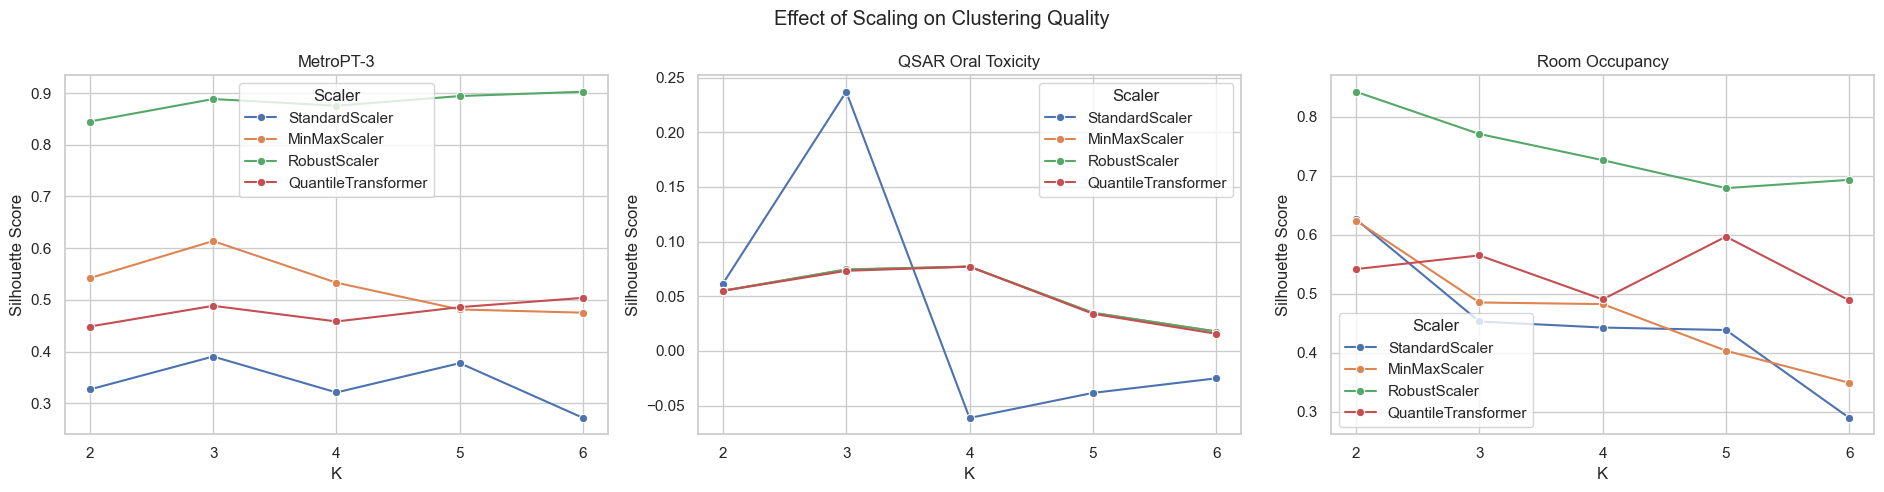

In [54]:
# Combine scaling results from all three datasets
all_scaling_results = pd.concat(
    [
        room_scaling_results,
        qsar_scaling_results,
        metro_scaling_results
    ],
    ignore_index=True
)

# Select the highest-Silhouette result for each dataset
best_scaling_results = all_scaling_results.loc[
    all_scaling_results.groupby("Dataset")[
        "Silhouette"
    ].idxmax()
].reset_index(drop=True)

print("Best scaling result for each dataset:")
display(best_scaling_results)

# Plot Silhouette score against K for each scaler
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for axis, (dataset_name, dataset_results) in zip(
    axes,
    all_scaling_results.groupby("Dataset")
):
    sns.lineplot(
        data=dataset_results,
        x="K",
        y="Silhouette",
        hue="Scaler",
        marker="o",
        ax=axis
    )
    axis.set_title(dataset_name)
    axis.set_ylabel("Silhouette Score")
    axis.set_xticks(range(2, 7))

plt.suptitle("Effect of Scaling on Clustering Quality")
plt.tight_layout()
plt.show()

**Observation:** Scaling affects each dataset differently. RobustScaler performed best for Room Occupancy and MetroPT-3, while StandardScaler performed best for QSAR. Therefore, scaling must be selected using experimental evidence rather than one fixed method.

In [55]:
# Ensure the processed-data folder exists
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save Room Occupancy features with the held-out evaluation label
room_processed = room_features_clean.copy()
room_processed["Room_Occupancy_Count"] = room_labels.to_numpy()

room_processed.to_csv(
    PROCESSED_DIR / "room_occupancy_processed.csv",
    index=False
)

# Save cleaned QSAR fingerprints with the held-out evaluation label
qsar_processed = qsar_features_reduced.copy()
qsar_processed["Toxicity_Class"] = qsar_labels.to_numpy()

qsar_processed.to_csv(
    PROCESSED_DIR / "qsar_oral_toxicity_processed.csv",
    index=False
)

# Save aggregated MetroPT-3 features with timestamp and window count
metro_processed = metro_features_clean.copy()
metro_processed.insert(
    0,
    "Window_Observation_Count",
    metro_window_counts
)
metro_processed = metro_processed.reset_index()

metro_processed.to_csv(
    PROCESSED_DIR / "metropt3_10min_processed.csv",
    index=False
)

# Save all quantitative scaling results
all_scaling_results.to_csv(
    PROCESSED_DIR / "scaling_comparison_results.csv",
    index=False
)

print("All processed datasets and scaling results were saved successfully.")

All processed datasets and scaling results were saved successfully.


In [56]:
# Reload each saved dataset to verify its shape and missing values
saved_files = {
    "Room Occupancy": PROCESSED_DIR / "room_occupancy_processed.csv",
    "QSAR Oral Toxicity": PROCESSED_DIR / "qsar_oral_toxicity_processed.csv",
    "MetroPT-3": PROCESSED_DIR / "metropt3_10min_processed.csv",
    "Scaling Results": PROCESSED_DIR / "scaling_comparison_results.csv"
}

verification_results = []

for name, file_path in saved_files.items():
    saved_data = pd.read_csv(file_path)

    verification_results.append({
        "File": name,
        "Rows": saved_data.shape[0],
        "Columns": saved_data.shape[1],
        "Missing Values": saved_data.isnull().sum().sum()
    })

display(pd.DataFrame(verification_results))

,File,Rows,Columns,Missing Values
0,Room Occupancy,10129,16,0
1,QSAR Oral Toxicity,8515,1013,0
2,MetroPT-3,25521,38,0
3,Scaling Results,60,6,0


### 6. Conclusion

All three datasets were successfully selected, inspected, and prepared for later experiments.

- Room Occupancy was reduced to 15 sensor features after removing one redundant temperature feature.
- QSAR was cleaned by removing duplicates and 12 strongly correlated fingerprints, leaving 1,012 features.
- MetroPT-3 was reduced from 1,516,948 readings to 25,521 ten-minute windows with 36 sensor-derived features.
- Extreme MetroPT-3 values were retained because they may represent genuine failures.
- Four scaling methods were compared quantitatively. RobustScaler performed best for Room Occupancy and MetroPT-3, while StandardScaler performed best for QSAR.

The cleaned datasets were saved in `datasets/processed/` and will be loaded in the next notebook for clustering and dimensionality-reduction experiments.